In [3]:
import pandas as pd
df = pd.read_csv('creditcard.csv')

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (284807, 31)


In [4]:
#check first 5 rows 
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
#count the fraud and legitimate transactions
print("Transaction counts:")
print(df['Class'].value_counts())

print("\nAs percentage:")
print(df['Class'].value_counts(normalize=True).mul(100).round(3))


Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

As percentage:
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_17900\2617131891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=df, palette=['#378ADD','#E24B4A'])


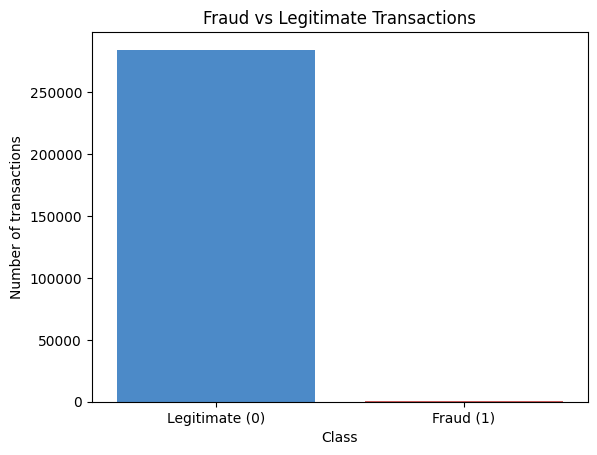

In [8]:
#Visualize the imbalance in form of chart
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class',data=df, palette=['#378ADD','#E24B4A'])
plt.title('Fraud vs Legitimate Transactions')
plt.xticks([0,1],['Legitimate (0)','Fraud (1)'])
plt.ylabel('Number of transactions')
plt.show()

In [9]:
#compare amonut of money in fradulent with legitimate transactions
print(df.groupby('Class')['Amount'].describe().round(2))

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']]) #double squares bracket for column header
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Time','Amount'],axis = 1)
print("Scaling done!")
print("New shape:",df.shape)


Scaling done!
New shape: (284807, 31)


In [11]:
#Seperate the inputs from answers
X = df.drop('Class' ,axis = 1)
y = df['Class'] 

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX columns:", list(X.columns))
print("\ny values (first 5):", list(y[:5]))

X shape: (284807, 30)
y shape: (284807,)

X columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']

y values (first 5): [0, 0, 0, 0, 0]


In [12]:
#fix imbalanace 
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#Split data into training and testing FIRST 
X_train ,X_test ,y_train,y_test = train_test_split(X,y ,test_size = 0.2 ,random_state=42)
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [13]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_bal.value_counts())


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [14]:
#Train Linear regression model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)

print("Logistic Regression trained!")


Logistic Regression trained!


In [20]:
#Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

print("Random Forest trained!")

Random Forest trained!


In [21]:
#XGBoost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal)

print("XGBoost trained!")

XGBoost trained!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on test data
lr_preds  = lr_model.predict(X_test)
rf_preds  = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Logistic Regression results
print("=" * 50)
print("LOGISTIC REGRESSION:")
print(classification_report(y_test, lr_preds))

# Random Forest results
print("=" * 50)
print("RANDOM FOREST:")
print(classification_report(y_test, rf_preds))

# XGBoost results
print("=" * 50)
print("XGBOOST:")
print(classification_report(y_test, xgb_preds))

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

RANDOM FOREST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

XGBOOST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.85      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.90     56962
weighted avg       1.00      

In [24]:
#Saving the best model
import joblib

joblib.dump(rf_model,'fraud_detection_model.pkl')

print("Model saved successfully!")
print("File name: fraud_detection_model.pkl")

Model saved successfully!
File name: fraud_detection_model.pkl
